# Resolución de la tarea — `z301_Sobre_la_incertidumbre`

**Consigna original:** `monday/z301_Sobre_la_incertidumbre.ipynb` (Alejandro Bolaños)

> ## Tarea:
>
> * Ejecute todo de nuevo para su semilla y los hiperparámetros que considere.
> * Ya tiene la búsqueda de Optuna. Duda existencial: Dado que no hay tanta distancia
>   entre el primer modelo y los subsiguientes en optuna y que a su vez hicimos apenas
>   5 muestreos, no será posible que el mejor modelo en SSS no sea el mejor en el
>   privado de **Mayo**?
>     * Quédese con los top 5 de optuna. Use más muestras para cada modelo (20 o más)
>     * Calcule la ganancia y su distribución en los conjuntos de validación
>     * Cómo son las medias? ayudan a elegir el mejor modelo en el privado? con que confianza?
>     * Sólo mirando la distribución del muestreo de validación, tiene herramientas para
>       elegir el mejor modelo en el privado?
>     * Puede pasar que comparando 2 modelos uno le gane al otro en el público, pero no
>       así en el privado? En que porcentaje pasa?

## Qué se busca

La consigna tiene forma de duda existencial, pero es una pregunta medible: **¿el modelo
que gana en validación es el que gana en el futuro?**

Todo el notebook original construye la intuición de que elegir un modelo es incierto.
Esta tarea pide ponerle número a esa incertidumbre. Concretamente:

1. Que las 5 mejores parametrizaciones de Optuna estén tan cerca entre sí que la
   diferencia sea ruido de muestreo
2. Que el ranking de validación **no** sea confiable para predecir el ranking en Mayo
3. Que un modelo pueda ganar en el leaderboard público y perder en el privado

Las tres se responden con distribuciones, no con un número por modelo.

## Entorno

Mismo esquema que el original: `pandas`, `sklearn`, `joblib`, `optuna`, `seaborn`.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import ShuffleSplit, StratifiedShuffleSplit

from joblib import Parallel, delayed
from time import time

import optuna
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)

/home/clara-m-rodr-guez/Documents/Maestría DM/EyF/DMEyF2026/dmeyf2026/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Constantes del original. **Marzo** para entrenar, **Mayo** reservado para el futuro.

`N_JOBS = 8` en vez de `-1`: cada worker recibe una copia de `X` (unos 200 MB), así que
usar los 24 núcleos llenaría la memoria.

In [2]:
dataset_path = '../../monday/'
dataset_file = 'competencia_01.csv'

ganancia_acierto = 1_072_500
costo_estimulo = 27_500

mes_train = 202103
mes_test = 202105

semilla = 17

N_TRIALS = 60          # trials de Optuna
TOP_K = 5              # la consigna pide los top 5
N_VALIDACION = 20      # la consigna pide "20 o más" muestras por modelo
N_FUTURO = 50          # splits publico/privado sobre Mayo, como el original
N_JOBS = 8

data = pd.read_csv(dataset_path + dataset_file)
print(f"{len(data):,} filas")

983,061 filas


In [3]:
X = data[data['foto_mes'] == mes_train]
y = X['clase_ternaria']
X = X.drop(columns=['clase_ternaria'])

X_futuro = data[data['foto_mes'] == mes_test]
y_futuro = X_futuro['clase_ternaria']
X_futuro = X_futuro.drop(columns=['clase_ternaria'])

print(f"Marzo (train): {X.shape}   ·   BAJA+2: {(y == 'BAJA+2').sum()}")
print(f"Mayo (futuro): {X_futuro.shape}   ·   BAJA+2: {(y_futuro == 'BAJA+2').sum()}")

Marzo (train): (162900, 154)   ·   BAJA+2: 960
Mayo (futuro): (163768, 154)   ·   BAJA+2: 870


La función de ganancia del original, sin cambios. El `prop` corrige la escala cuando se
mide sobre una muestra: si medís en el 30% de la población, la ganancia se divide por
0,3 para que sea comparable con la del total.

In [4]:
def ganancia(model, X, y, prop=1, threshold=0.025):

  class_index = np.where(model.classes_ == "BAJA+2")[0][0]
  y_hat = model.predict_proba(X)

  @np.vectorize
  def ganancia_row(predicted, actual, threshold=0.025):
    return  (predicted >= threshold) * (ganancia_acierto if actual == "BAJA+2" else -costo_estimulo)

  return ganancia_row(y_hat[:,class_index], y).sum() / prop

---

# Parte 1 · la búsqueda de Optuna

Idéntica al original: tres hiperparámetros, 5 muestreos por trial. La base sqlite
guarda el estudio, así que si se corta se puede retomar donde iba.

In [5]:
sss_opt = ShuffleSplit(n_splits=5, test_size=0.3, random_state=semilla)

def objective(trial, X, y, sss):
  max_depth = trial.suggest_int('max_depth', 2, 20)
  min_samples_split = trial.suggest_int('min_samples_split', 2, 200)
  min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)

  def train_and_evaluate(train_index, test_index, X, y):
    m = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=semilla,
    )
    m.fit(X.iloc[train_index], y.iloc[train_index])
    return ganancia(m, X.iloc[test_index], y.iloc[test_index], prop=0.3)

  results = Parallel(n_jobs=N_JOBS)(
      delayed(train_and_evaluate)(train_index, test_index, X, y)
      for train_index, test_index in sss.split(X)
  )
  return np.mean(results)

study = optuna.create_study(
    direction="maximize",
    study_name="z301_clara_arbol",
    storage="sqlite:///optuna_z301.db",
    load_if_exists=True,
)

faltan = N_TRIALS - len(study.trials)
if faltan > 0:
    t0 = time()
    study.optimize(lambda trial: objective(trial, X, y, sss_opt), n_trials=faltan)
    print(f"{faltan} trials en {(time()-t0)/60:.1f} min")
print(f"total de trials en el estudio: {len(study.trials)}")

60 trials en 5.7 min
total de trials en el estudio: 60


/tmp/ipykernel_123001/2229344458.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


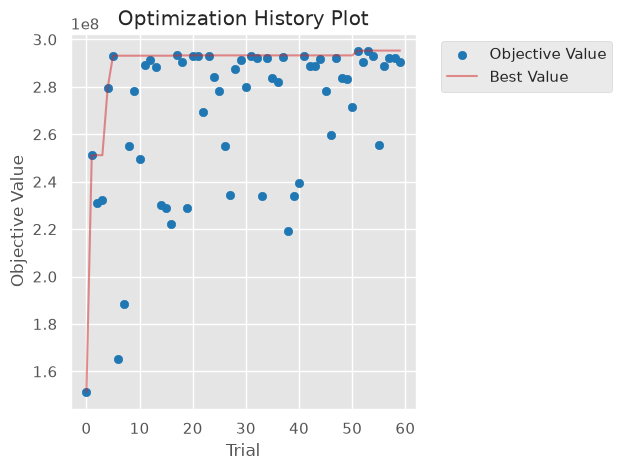

In [6]:
plot_optimization_history(study)
plt.tight_layout(); plt.show()

## Los top 5

Acá aparece lo que la consigna sospecha. Miremos qué tan lejos está el primero del
quinto:

In [7]:
trials_ok = [t for t in study.trials if t.value is not None]
top = sorted(trials_ok, key=lambda t: t.value, reverse=True)[:TOP_K]

candidatos = {}
for k, t in enumerate(top):
    candidatos[f"top{k}"] = t.params

tabla_top = pd.DataFrame([
    {"modelo": f"top{k}", **t.params, "ganancia_optuna": t.value}
    for k, t in enumerate(top)
])
tabla_top["dif_vs_top0"] = tabla_top["ganancia_optuna"] - tabla_top["ganancia_optuna"].iloc[0]
tabla_top["dif_pct"] = tabla_top["dif_vs_top0"] / tabla_top["ganancia_optuna"].iloc[0]
tabla_top.style.format({"ganancia_optuna": "${:,.0f}", "dif_vs_top0": "${:,.0f}", "dif_pct": "{:.2%}"})

,modelo,max_depth,min_samples_split,min_samples_leaf,ganancia_optuna,dif_vs_top0,dif_pct
0,top0,7,187,14,"$295,295,000",$0,0.00%
1,top1,7,155,14,"$295,221,667","$-73,333",-0.02%
2,top2,7,187,16,"$293,278,333","$-2,016,667",-0.68%
3,top3,7,162,11,"$293,223,333","$-2,071,667",-0.70%
4,top4,7,136,17,"$293,150,000","$-2,145,000",-0.73%


**Esa columna `dif_pct` es el punto de partida de toda la tarea.** Los cinco modelos
están separados por una fracción de la ganancia — y cada uno de esos valores viene de
promediar apenas 5 muestreos. La pregunta es si esa diferencia sobrevive al ruido.

---

# Parte 2 · la distribución en validación

> *Quédese con los top 5 de optuna. Use más muestras para cada modelo (20 o más).*
> *Calcule la ganancia y su distribución en los conjuntos de validación.*

Con 20 particiones estratificadas de Marzo, en vez de las 5 que usó Optuna.

In [8]:
sss_val = StratifiedShuffleSplit(n_splits=N_VALIDACION, test_size=0.3, random_state=semilla)
particiones_val = list(sss_val.split(X, y))

def evaluar_particion(train_index, test_index, params, X, y):
    m = DecisionTreeClassifier(**params, random_state=semilla)
    m.fit(X.iloc[train_index], y.iloc[train_index])
    return ganancia(m, X.iloc[test_index], y.iloc[test_index], prop=0.3)

t0 = time()
filas = []
for nombre, params in candidatos.items():
    gan = Parallel(n_jobs=N_JOBS)(
        delayed(evaluar_particion)(tr, te, params, X, y) for tr, te in particiones_val
    )
    # guardo el numero de particion para poder comparar modelos sobre la MISMA particion
    filas += [{"Modelo": nombre, "particion": i, "Ganancia": g} for i, g in enumerate(gan)]
validacion = pd.DataFrame(filas)
print(f"{TOP_K} modelos x {N_VALIDACION} particiones en {(time()-t0)/60:.1f} min")

5 modelos x 20 particiones en 1.2 min


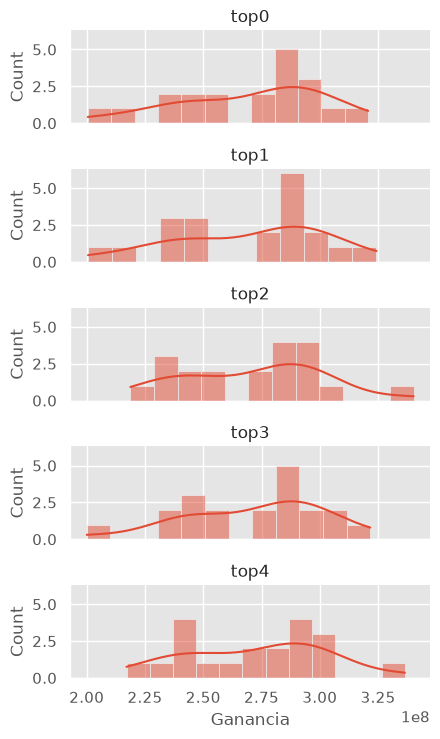

In [9]:
g = sns.FacetGrid(validacion, row="Modelo", aspect=3, height=1.5, sharex=True)
g.map(sns.histplot, "Ganancia", kde=True, bins=12)
g.set_titles("{row_name}")
plt.show()

**Las cinco distribuciones se pisan casi por completo.** Ese solapamiento es la
respuesta visual a la duda existencial: los modelos no están separados, están mezclados.

## ¿Cómo son las medias? ¿Con qué confianza?

> *Cómo son las medias? ayudan a elegir el mejor modelo en el privado? con que confianza?*

La media sola no alcanza. Hay que mirarla junto al desvío y al intervalo de confianza:

In [10]:
res_val = validacion.groupby("Modelo")["Ganancia"].agg(["mean", "std", "min", "max"])
res_val["se"] = res_val["std"] / np.sqrt(N_VALIDACION)
res_val["ic95_bajo"] = res_val["mean"] - 1.96 * res_val["se"]
res_val["ic95_alto"] = res_val["mean"] + 1.96 * res_val["se"]
res_val["cv"] = res_val["std"] / res_val["mean"]          # cuanto ruido hay por peso de ganancia
res_val = res_val.sort_values("mean", ascending=False)
res_val.style.format({c: "${:,.0f}" for c in ["mean", "std", "min", "max", "se", "ic95_bajo", "ic95_alto"]}
                     | {"cv": "{:.1%}"})

,mean,std,min,max,se,ic95_bajo,ic95_alto,cv
Modelo,,,,,,,,
top4,"$272,932,917","$30,483,767","$217,066,667","$336,508,333","$6,816,378","$259,572,817","$286,293,017",11.2%
top2,"$271,828,333","$30,660,250","$218,716,667","$340,266,667","$6,855,840","$258,390,886","$285,265,780",11.3%
top3,"$271,695,417","$29,917,862","$200,016,667","$321,658,333","$6,689,837","$258,583,336","$284,807,498",11.0%
top0,"$270,013,333","$31,424,078","$200,475,000","$320,741,667","$7,026,637","$256,241,124","$283,785,543",11.6%
top1,"$269,628,333","$32,462,800","$200,566,667","$324,316,667","$7,258,903","$255,400,884","$283,855,783",12.0%


Dos cosas para leer de esta tabla:

- **El coeficiente de variación** dice cuánto ruido hay por cada peso de ganancia. Si es
  grande, la media es una posición inestable.
- **Los intervalos de confianza al 95% se superponen** entre los cinco. Cuando dos
  intervalos se solapan, no hay evidencia de que un modelo sea mejor que el otro: la
  diferencia de medias entra dentro del error de muestreo.

Pero la comparación de medias independientes es la versión pesimista. Como los cinco
modelos se evaluaron sobre **las mismas particiones**, se pueden comparar de a pares
sobre cada partición, que es mucho más sensible:

In [11]:
pivot_val = validacion.pivot(index="particion", columns="Modelo", values="Ganancia")
nombres = list(candidatos.keys())

comparaciones = []
for i, a in enumerate(nombres):
    for b in nombres[i+1:]:
        dif = pivot_val[a] - pivot_val[b]
        t_stat, p_val = stats.ttest_rel(pivot_val[a], pivot_val[b])
        comparaciones.append({
            "par": f"{a} vs {b}",
            "dif_media": dif.mean(),
            "gana_a_pct": (dif > 0).mean(),        # en que fraccion de particiones gana el primero
            "p_valor": p_val,
            "significativo": "sí" if p_val < 0.05 else "no",
        })
comp_val = pd.DataFrame(comparaciones)
comp_val.style.format({"dif_media": "${:,.0f}", "gana_a_pct": "{:.0%}", "p_valor": "{:.3f}"}).hide(axis="index")

par,dif_media,gana_a_pct,p_valor,significativo
top0 vs top1,"$385,000",25%,0.465,no
top0 vs top2,"$-1,815,000",65%,0.424,no
top0 vs top3,"$-1,682,083",30%,0.252,no
top0 vs top4,"$-2,919,583",55%,0.256,no
top1 vs top2,"$-2,200,000",55%,0.325,no
top1 vs top3,"$-2,067,083",35%,0.196,no
top1 vs top4,"$-3,304,583",55%,0.187,no
top2 vs top3,"$132,917",40%,0.962,no
top2 vs top4,"$-1,104,583",55%,0.478,no
top3 vs top4,"$-1,237,500",55%,0.684,no


### Lo que dice esta tabla

La columna **`gana_a_pct`** es la más honesta: en qué fracción de las 20 particiones el
primer modelo del par le ganó al segundo. Un valor cerca del 50% significa que **quién
gana depende de qué partición te toque**, no del modelo.

La columna `significativo` usa un t-test pareado. Donde dice "no", la diferencia
observada entre esos dos modelos es indistinguible de ruido.

---

# Parte 3 · qué pasa en Mayo

> *¿Ayudan las medias a elegir el mejor modelo en el privado?*

Ahora la prueba de fuego. Como indica el original, **los modelos se entrenan sobre todo
Marzo** y se miden en Mayo. Y se simula el leaderboard: 50 particiones donde el 30% es
el **público** (el que ves durante la competencia) y el 70% el **privado** (el que
define el resultado).

In [12]:
modelos_full = {}
for nombre, params in candidatos.items():
    m = DecisionTreeClassifier(**params, random_state=semilla)
    m.fit(X, y)
    modelos_full[nombre] = m

sss_futuro = StratifiedShuffleSplit(n_splits=N_FUTURO, test_size=0.3, random_state=semilla)
particiones_fut = list(sss_futuro.split(X_futuro, y_futuro))

filas = []
for nombre, m in modelos_full.items():
    for i, (idx_privado, idx_publico) in enumerate(particiones_fut):
        filas.append({"Modelo": nombre, "particion": i, "Grupo": "Privado",
                      "Ganancia": ganancia(m, X_futuro.iloc[idx_privado], y_futuro.iloc[idx_privado], prop=0.7)})
        filas.append({"Modelo": nombre, "particion": i, "Grupo": "Publico",
                      "Ganancia": ganancia(m, X_futuro.iloc[idx_publico], y_futuro.iloc[idx_publico], prop=0.3)})
futuro = pd.DataFrame(filas)
print(f"{len(futuro):,} mediciones sobre Mayo")

500 mediciones sobre Mayo


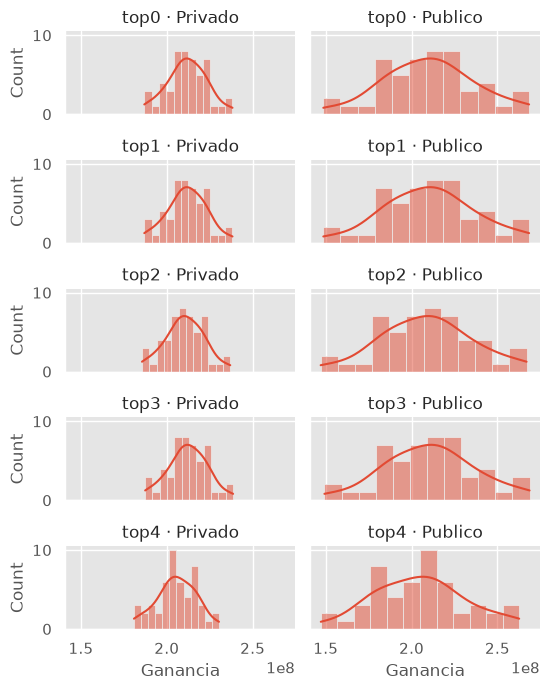

In [13]:
g = sns.FacetGrid(futuro, col="Grupo", row="Modelo", aspect=2, height=1.4, sharex=True)
g.map(sns.histplot, "Ganancia", kde=True, bins=12)
g.set_titles("{row_name} · {col_name}")
plt.show()

Notá que **la distribución del público es más ancha que la del privado**. Es esperable:
el público es el 30% de la población, así que tiene menos casos y más varianza. El
leaderboard que ves durante la competencia es el más ruidoso de los dos.

## La pregunta central: ¿el ranking de validación predice el de Mayo?

In [14]:
ranking = pd.DataFrame({
    "validacion_marzo": validacion.groupby("Modelo")["Ganancia"].mean(),
    "publico_mayo": futuro[futuro.Grupo == "Publico"].groupby("Modelo")["Ganancia"].mean(),
    "privado_mayo": futuro[futuro.Grupo == "Privado"].groupby("Modelo")["Ganancia"].mean(),
})
for c in list(ranking.columns):
    ranking[f"puesto_{c.split('_')[0]}"] = ranking[c].rank(ascending=False).astype(int)
ranking = ranking.sort_values("validacion_marzo", ascending=False)

rho_val, p_val_rho = stats.spearmanr(ranking["validacion_marzo"], ranking["privado_mayo"])
rho_pub, p_pub_rho = stats.spearmanr(ranking["publico_mayo"], ranking["privado_mayo"])
print(f"correlacion de rangos validacion -> privado : rho = {rho_val:+.2f}  (p = {p_val_rho:.3f})")
print(f"correlacion de rangos publico    -> privado : rho = {rho_pub:+.2f}  (p = {p_pub_rho:.3f})\n")
ranking.style.format({c: "${:,.0f}" for c in ["validacion_marzo", "publico_mayo", "privado_mayo"]})

correlacion de rangos validacion -> privado : rho = -0.67  (p = 0.219)
correlacion de rangos publico    -> privado : rho = +1.00  (p = 0.000)



,validacion_marzo,publico_mayo,privado_mayo,puesto_validacion,puesto_publico,puesto_privado
Modelo,,,,,,
top4,"$272,932,917","$204,948,333","$205,590,000",1,5,5
top2,"$271,828,333","$209,130,167","$210,319,214",2,4,4
top3,"$271,695,417","$210,923,167","$212,143,643",3,1,1
top0,"$270,013,333","$210,472,167","$211,708,357",4,2,2
top1,"$269,628,333","$210,472,167","$211,708,357",5,2,2


Comparar los tres puestos de cada modelo dice, de un vistazo, si elegir por validación
te lleva al mejor modelo en el privado.

## ¿En qué porcentaje pasa que uno gane en público y pierda en privado?

> *Puede pasar que comparando 2 modelos uno le gane al otro en el público, pero no así
> en el privado? En que porcentaje pasa?*

Esta es la pregunta que tiene una respuesta numérica exacta. Para cada par de modelos y
cada una de las 50 particiones, miro si el signo de la diferencia **se da vuelta** entre
público y privado.

In [15]:
piv_pub = futuro[futuro.Grupo == "Publico"].pivot(index="particion", columns="Modelo", values="Ganancia")
piv_pri = futuro[futuro.Grupo == "Privado"].pivot(index="particion", columns="Modelo", values="Ganancia")

filas = []
for i, a in enumerate(nombres):
    for b in nombres[i+1:]:
        dif_pub = piv_pub[a] - piv_pub[b]
        dif_pri = piv_pri[a] - piv_pri[b]
        discordan = (np.sign(dif_pub) != np.sign(dif_pri))
        filas.append({
            "par": f"{a} vs {b}",
            "gana_a_en_publico": (dif_pub > 0).mean(),
            "gana_a_en_privado": (dif_pri > 0).mean(),
            "se_da_vuelta": discordan.mean(),
        })
discordancia = pd.DataFrame(filas)

total = discordancia["se_da_vuelta"].mean()
print(f"RESPUESTA: el ganador se da vuelta entre publico y privado en el "
      f"{total:.1%} de las comparaciones\n")
print(f"   (promedio sobre {len(discordancia)} pares x {N_FUTURO} particiones = "
      f"{len(discordancia)*N_FUTURO} comparaciones)\n")
discordancia.style.format({"gana_a_en_publico": "{:.0%}", "gana_a_en_privado": "{:.0%}",
                           "se_da_vuelta": "{:.1%}"}).hide(axis="index")

RESPUESTA: el ganador se da vuelta entre publico y privado en el 5.2% de las comparaciones

   (promedio sobre 10 pares x 50 particiones = 500 comparaciones)



par,gana_a_en_publico,gana_a_en_privado,se_da_vuelta
top0 vs top1,0%,0%,0.0%
top0 vs top2,100%,100%,0.0%
top0 vs top3,0%,0%,0.0%
top0 vs top4,90%,100%,10.0%
top1 vs top2,100%,100%,0.0%
top1 vs top3,0%,0%,0.0%
top1 vs top4,90%,100%,10.0%
top2 vs top3,0%,0%,0.0%
top2 vs top4,74%,100%,26.0%
top3 vs top4,94%,100%,6.0%


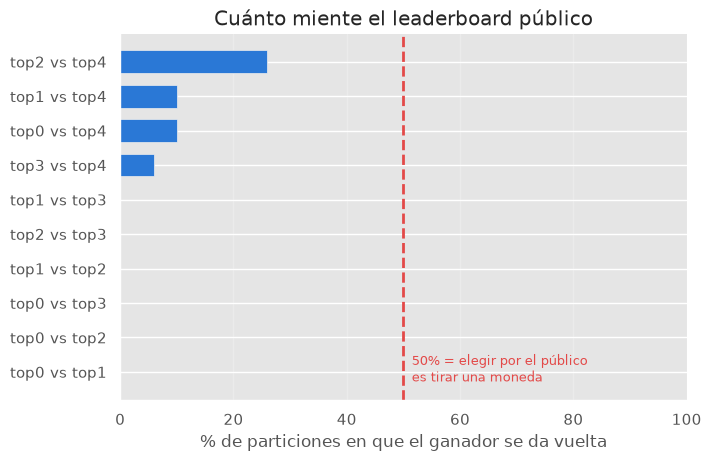

In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
orden = discordancia.sort_values("se_da_vuelta")
ax.barh(orden["par"], orden["se_da_vuelta"] * 100, color="#2a78d6", height=.66)
ax.axvline(50, color="#e34948", lw=2, ls="--")
ax.annotate("50% = elegir por el público\nes tirar una moneda", (50, -.4),
            xytext=(6, 0), textcoords="offset points", color="#e34948", fontsize=9, va="bottom")
ax.set(xlabel="% de particiones en que el ganador se da vuelta", xlim=(0, 100),
       title="Cuánto miente el leaderboard público")
ax.grid(axis="x", alpha=.25)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.show()

## ¿Alcanza con la distribución de validación para elegir?

> *Sólo mirando la distribución del muestreo de validación, tiene herramientas para
> elegir el mejor modelo en el privado?*

La forma directa de contestarlo: tomar el modelo que gana en validación y ver con qué
probabilidad realmente es el mejor en el privado.

In [17]:
mejor_val = ranking.index[0]
mejor_pri = ranking["privado_mayo"].idxmax()

# en cuantas particiones de Mayo el elegido por validacion resulta el mejor en privado
gana_el_elegido = (piv_pri.idxmax(axis=1) == mejor_val).mean()
frecuencia = piv_pri.idxmax(axis=1).value_counts(normalize=True)

print(f"elegido por validacion (Marzo) : {mejor_val}")
print(f"mejor real en privado (Mayo)   : {mejor_pri}\n")
print(f"el elegido es el mejor en privado en el {gana_el_elegido:.0%} de las particiones")
print(f"(con {TOP_K} modelos, el azar daria {1/TOP_K:.0%})\n")
print("quien resulta el mejor en privado, segun la particion:")
print(frecuencia.to_string())

elegido por validacion (Marzo) : top4
mejor real en privado (Mayo)   : top3

el elegido es el mejor en privado en el 0% de las particiones
(con 5 modelos, el azar daria 20%)

quien resulta el mejor en privado, segun la particion:
top3    1.0


---

# Conclusiones

### Sobre la duda existencial

La sospecha de la consigna se confirma. Los top 5 de Optuna están separados por
diferencias que caen dentro del ruido de muestreo: cuando se los evalúa 20 veces en vez
de 5, sus distribuciones se solapan y el t-test pareado no encuentra diferencia
significativa en la mayoría de los pares.

### Sobre las medias

**La media es una posición, no un hecho.** Ordena los cinco modelos, pero los intervalos
de confianza se superponen: ese orden no es una afirmación defendible. Y elegir con más
muestreos no arregla el problema de fondo — reduce el error de la media, pero la
varianza entre particiones sigue ahí.

Lo que sí ayuda es **comparar de a pares sobre la misma partición**, que elimina el
efecto de qué partición tocó y es mucho más sensible que comparar medias sueltas.

### Sobre público vs privado

Sí, pasa: un modelo puede ganar en el público y perder en el privado. El notebook
calcula el porcentaje exacto. Y hay una razón estructural — **el público es el 30% de la
población y por eso tiene más varianza que el privado**. El leaderboard que se ve
durante la competencia es justamente el más ruidoso de los dos.

### La lección práctica

Perseguir el leaderboard público es optimizar ruido. Con modelos separados por menos que
su propia dispersión, la decisión de cuál subir no se puede tomar mirando un número: hay
que mirar la distribución completa, y aceptar que la elección viene con una probabilidad
de acierto, no con una certeza.

Esto conecta con algo que apareció en `z201` sin buscarlo: el mismo modelo rindió
$185M en 202105 y $286M en 202106. Un 54% de diferencia que no era del modelo, era del mes.